##Parâmetros da Simulação

In [1]:
import numpy as np
import random
K= 512 #tamanho da chave
L = 412  #tamanho da tag e da mensagem
N = 10**3
rho_s = np.sqrt(0.985)  # alocação de potência para a mensagem
snr_db = 10
eta = 0.0000001 #1% default

# Mensagem e Modulação BPSK#


In [2]:
#mensagem modulada de comprimento K com alfabeto de [1,-1]
def modulator_bpsk(L, seed=None):
    s_bin = np.random.randint(0, 2, size=L)
    s_bpsk = 1 - 2 * s_bin  # mapeia 0→+1, 1→-1
    return s_bin, s_bpsk


#Geração das TAGs


In [3]:
a, b, c = 6, 1, 1
def Mfunc(x, K):
    return (a * x**2 + b * x + c) % (2**K)
#def tentmap(x):
#    if -1 <= x < 0:
#        return 2 * x + 0.9999
#    elif 0 <= x <= 1:
#        return -2 * x + 0.9999
#    else:
#        return 0  # fora do domínio esperado

def tentmap(x, beta=0.000001):
    if x == None: #condição inicial
        x = np.random.uniform(-1, 1) #escolhida aleatoriamente neste caso
    if x < beta:
        return 2/(beta+1)*x + (1-beta)/(beta+1) #~ 2x +1
    else:
        return 2/(beta-1)*x - (beta+1)/(beta-1) #~ 2x -1

def orbit(x0, steps):
    x = x0
    xorbit=[] #ponto inicial S0_(y)
    for i in range(steps):
        x = tentmap(x)
        xorbit.append(x)
    return xorbit

# Geração de TAG de comprimento L com 1 órbita por símbolo
def generate_tag(L, K, bits_msg, chave,x0=None):
    sigma = K - L  # pontos a descartar
    steps_total = K
    tags = []
    #Condicao inicial
    if x0 == None: #geração legitima
      #k_repeated = np.resize(k, L)
      m_filled = np.resize(bits_msg,K) #estende a mensagem para o mesmo tamanho da chave
      s_xor_k = np.bitwise_xor(m_filled, chave)
      # Converte vetor binário para inteiro
      xor_value = int("".join(str(b) for b in s_xor_k), 2)
      xi = Mfunc(xor_value, K=K)
      x0_norm =  (xi / (2**K - 1)) * 2 - 1  # normaliza para [-1, 1] # para que fique no alfabeto do mapa da tenda
    else:
      xi =x0 #geração falsa
    #gera orbita completa
    orb = orbit(x0_norm, K) # Iterar sigma + L vezes
    orb_descarte = orb[sigma:]  # descarta os sigma pontos
    return np.array(orb_descarte)

In [10]:
chave= np.random.randint(0, 2, K)
bits_msg, bpsk_msg = modulator_bpsk(L)
tag = generate_tag(L, K, bits_msg, chave)
print("Media msg:", np.mean(bpsk_msg))
print("Media tag:", np.mean(tag))
print("Variancia :", np.var(tag))
print("Media do quadrado/potencia:", np.mean(tag**2))


Media msg: 0.05339805825242718
Media tag: 0.021557237266711177
Variancia : 0.31827070698795606
Media do quadrado/potencia: 0.3187354214665294


In [11]:
""" variavel em analise: tau|H0
media = np.mean(tau|H0)                # E[tau|H0] #valor esperado
energia_media = np.mean(tau_H0**2)     # E[tau^2|H0] #potencia
variancia = energia_media - media**2   # Var[tau|H0]
"""

rho_t = np.sqrt((1 - rho_s**2) / np.mean(tag**2))
y= ((1-rho_s)/rho_t)*bpsk_msg
tau_H0 = np.sum(y*tag) #propria variavel
print(tau_H0)
E_tau_H0 = np.mean(tau_H0) #Valor esperado
print(E_tau_H0)
Pot_tau = np.mean(tau_H0**2) #media da energia (soma dos valores quadraticos) =potencia
print(Pot_tau)
var= Pot_tau - (E_tau_H0)**2 #var é a do ruido
print(var)


0.07281722412154884
0.07281722412154884
0.005302348128767874
0.0


#Transmissão#


In [12]:
# --- Energia da TAG ---
def compute_tag_power(tag):
    """
    Calcula a energia média - POTENCIA - de uma única tag (um vetor).
    """
    return np.mean(tag**2) #media da energia do sinal é a potencia média, precisa ser para que rho_s**2 + rho_t**2 =1


# --- Combina mensagem e tag ---
def combine_message_tag(s, tag, rho_s):
    """
    Combina uma mensagem BPSK (s) e uma tag (tag) em um único sinal x.
    """
    Ptag = compute_tag_power(tag)   # E[tag^2]
    rho_t = np.sqrt((1 - rho_s**2) / Ptag)  # normalização pela potencia da media tag

    # Combinação direta (mesmo tamanho: 1 símbolo de s ↔ 1 símbolo de tag)
    s = np.array(s)
    tag = np.array(tag)
    x = (rho_s * s) + (rho_t * tag)

    return x, rho_t


# --- Ruído AWGN ---
def gen_noise(snr_db, N):
    """
    Gera ruído gaussiano branco de tamanho N para um SNR dado.
    """
    snr_linear = 10**(snr_db / 10)
    Es = 1  # energia média do BPSK fixada
    sigma2w = Es / snr_linear  # variância do ruído
    noise = np.random.normal(0, np.sqrt(sigma2w), N)
    return sigma2w, noise


# --- Canal AWGN ---
def add_awgn(x, snr_db):
    """
    Adiciona ruído AWGN a um único sinal x.
    """
    sigma2w, noise = gen_noise(snr_db, len(x))
    y = x + noise
    return y, noise


##Recepção

In [13]:
def detect_tag(y, s, t_ref, rho_s, rho_t):
    """
    Calcula a estatística de decisão para UMA transmissão.
    """
    # Remove a contribuição da mensagem
    y_minus_msg = (y - rho_s * s) / rho_t

    # Correlação com TAG legítima (esperada)
    stat = np.sum(y_minus_msg * t_ref) #valor esperado ja é a correlacao

    return stat #tau


# Limiar de decisão e Matriz de Confusão

In [14]:
#Decodificador da dissertação:
from scipy.stats import norm
from scipy.special import erfc
import pytest

def Qfunc(x):
    """ Q function """
    return (0.5)*erfc(x/np.sqrt(2))

def thresh(stdDev,mean,alpha):
#    """ Finds the decision threshold for the hypothesis test """
    threshold = 0
    while Qfunc((threshold-mean)/stdDev) > alpha:
        threshold += 0.1
    return threshold
#def thresh(stdDev, mean, alpha):
#    return norm.isf(alpha) * stdDev + mean

#def thresh(std, mean, alpha):
#    return mean + std * norm.isf(alpha)

def tauVarCalc(sigma2w,len_message,rho_t, tag):
    sigma2tag = np.var(tag) #deve ser igual potencia media da tag
    #assert sigma2tag == compute_tag_power(tag), "Mismatch mean power and var"
    #assert abs(sigma2tag - compute_tag_power(tag)) < 1e-3
    tauVar = (sigma2tag*sigma2w*len_message)/(rho_t**2)
    return tauVar

def threshold_decision( sigma2w, len_message, rhot,tag, eta):
    """
    Decide entre H1 (TAG legítima) e H0 (sem TAG ou falsa),
    com base no limiar calculado pela expressão:
    Q(tau_i / sigma^2_vi) < eta
    """
    sigma2_v = tauVarCalc(sigma2w,len_message, rhot,tag)
    # Encontrar o menor τ_0 tal que Q(τ_0 / σ²_vi) < η
    tau0 = thresh(np.sqrt(sigma2_v), 0, eta) #para falso positivo, estamos na curva de H0, com media 0 e variancia sigma2v
    return tau0


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def compute_confusion_matrix(stat_H1, stat_H0, tau):

    y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])
    y_scores = np.concatenate([stat_H1, stat_H0])

    # Se tau for um único valor, repete para todas as transmissões
    if np.isscalar(tau):
        tau_vec = np.full_like(y_scores, fill_value=tau, dtype=float)
    else:
        tau_vec = np.array([tau[i % len(tau)] for i in range(len(y_scores))])

    # Aplica thresholds por transmissão
    y_pred = (y_scores >= tau_vec).astype(int)

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    TN, FP, FN, TP = cm.ravel()

    cm_normalized = cm.astype('float') / len(stat_H0)

    print(f"TP: {TP/len(stat_H1)}, FP: {FP/len(stat_H0)}, TN: {TN/len(stat_H0)}, FN: {FN/len(stat_H1)}")
    print(f"Accuracy: {(TP + TN) / len(y_true):.3f}")
    print(f"False Positive Rate: {FP:.3f}")
    print(f"False Negative Rate: {FN:.3f}")

    # Exibe a matriz
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=["H0", "H1"])
    disp.plot(cmap='Blues')
    plt.grid(False)
    plt.title("Matriz de Confusão")
    plt.show()


#Teste de Hipótese

In [30]:
#decisão
#H1: tag presente
#H0: sem tag
def simulate_hypothesis_test(L, K, N, rho_s, snr_db, chave,sigma2w,eta):
    all_stat_H1 = []
    all_stat_H0 = []
    tau_vec = []

    for n in range(N):
        # --- 1. Mensagem e modulação ---
        bits_msg, bpsk_msg = modulator_bpsk(L)

        # --- 2. Geração da TAG legítima ---
        tag_legit = generate_tag(L, K, bits_msg, chave)

        # --- 3. Combinação mensagem + TAG legítima ---
        x_tag, rho_t = combine_message_tag(bpsk_msg, tag_legit, rho_s)

        # --- 4. Canal AWGN para H1 ---
        y_legit, noise = add_awgn(x_tag, snr_db)

        # --- 5. Decisão sob H1 ---
        tau_H1 = detect_tag(y_legit, bpsk_msg, tag_legit, rho_s, rho_t)


        # --- 6. Geração de mensagem fraudulenta sem TAG (hipótese H0) ---
        #sob a mesma mensagem desta transmissao
        # --- 8. Canal AWGN para H0 (ruído independente do H1!) ---
        y_fake, _ = add_awgn(bpsk_msg, snr_db)

        # --- 9. Decisão sob H0 ---
        tau_H0 = detect_tag(y_fake,bpsk_msg, tag_legit, rho_s, rho_t)

        # 10) Threshold por transmissão
        tau_i = threshold_decision(sigma2w, L, rho_t, tag, eta)
        # --- 11. Armazena ---
        all_stat_H1.append(tau_H1)
        all_stat_H0.append(tau_H0)
        tau_vec.append(tau_i)

    return np.array(all_stat_H1), np.array(all_stat_H0), np.array(tau_vec)


##Simulação

#Segunda opcao de threshold (empírico e otimizado)



In [16]:
import numpy as np

def find_threshold_to_reduce_fp(stat_H1, stat_H0, eta, plot=True):
    # Concatenar todos os scores possíveis
    all_scores = np.sort(np.concatenate([stat_H1, stat_H0]))

    best_threshold = None
    best_fp = 1.0  # começa alto

    for tau in all_scores:
        fp = np.sum(stat_H0 >= tau) / len(stat_H0)

        # Queremos FP <= eta
        if fp <= eta:
            best_threshold = tau
            best_fp = fp
            break

    #print(f"Melhor threshold para FP ≤ {eta*100:.1f}%: {best_threshold:.4f}")
    #print(f"FPR (falso positivo): {best_fp*100:.2f}%")

    return best_threshold


TP: 1.0, FP: 0.0, TN: 1.0, FN: 0.0
Accuracy: 1.000
False Positive Rate: 0.000
False Negative Rate: 0.000


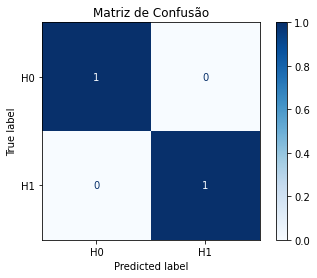

In [19]:
sigma2w, noise = gen_noise(snr_db, len(bpsk_msg)) # calcula a variancia do ruido inserido na mensagem
stat_H1, stat_H0= simulate_hypothesis_test(L, K, N, rho_s, snr_db, chave, sigma2w, eta)
threshold = find_threshold_to_reduce_fp(stat_H1, stat_H0, eta)
compute_confusion_matrix(stat_H1, stat_H0, threshold)



##Trade-offs

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FormatStrFormatter
from tqdm.notebook import tqdm

def fnr_vs_L_theoretical(K, N, snr_db, eta, rho_s):
    rho_t = np.sqrt((1 - rho_s**2)*3)
    SNR = 10**(snr_db / 10)
    L_max = K
    L_values = range(32, L_max, 32)  # Valores de L de 32 até L_max, passo de 32
    reuse = []
    auth_prob = []
    fnr_values = []
    for L in tqdm(L_values, desc="Calculando Prob Falso Negativo teórico", unit="L"):
        prob = 0
        energies =np.zeros((N,1))
        variancias=np.zeros((N,1))
        for i in range(50):
            # Gera amostras para hipótese H1 (tag legítima) e H0 (não legítima) (L, K, N, rho_s, snr_db, chave, sigma2w, eta)
            tau0=0
            for n in range(N):
              chave= np.random.randint(0, 2, L+32) ###joao aqui calcula a energia de toda a seq de uma so vez
              bits_msg, bpsk_msg = modulator_bpsk(L)
              tag = generate_tag(L,L+32, bits_msg, chave)
              #-------------------------------Simulação Teórica------------------------------------#
              #calculo da energia
              energies[n] = np.sum(tag**2) # = Energia(tau|H1)
              #calculo da variancia
              variancias[n] = np.var(tag)
            sigma2tag = np.mean(variancias)
            sigma2v= (sigma2tag*L)/(SNR*rho_t**2)
            tau0 = thresh(np.sqrt(sigma2v),0,eta) # vc escolhe H0 (media da energia (potencia) nula, nao ha tag. para caso da falsa essa seria outra media) quando deveria escolher H1
            prob += (1-Qfunc((tau0 - np.mean(energies)) / np.sqrt(sigma2v)))/50

        auth_prob.append(prob)
    return auth_prob




In [35]:
def fnr_vs_L_MonteCarlo(K, N, snr_db, eta, rho_s):
    L_max = K
    L_values = range(32, L_max, 32)  # Valores de L de 32 até L_max, passo de 32
    fnr_values = []

    for L in tqdm(L_values, desc="Calculando FNR Monte Carlo", unit="L"):
        fnr = 0
        for i in range(50):
            sigma2w, noise = gen_noise(snr_db, L)
            chave= np.random.randint(0, 2, L+32) #uma chave para cada uma das 50 simulações para cada valor de L
            #-------------------------------Simulação Monte Carlo - Numerical------------------------------------#
            stat_H1, stat_H0, threshold = simulate_hypothesis_test(L, L+32, N, rho_s, snr_db, chave, sigma2w, eta)
            #tau= find_threshold_to_reduce_fp(stat_H1, stat_H0, eta)
            y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])
            y_scores = np.concatenate([stat_H1, stat_H0])
            tau_vec = np.array([threshold[i % len(threshold)] for i in range(len(y_scores))])
            y_pred = (y_scores >= tau_vec).astype(int)
            cm = confusion_matrix(y_true, y_pred, labels=[0,1])
            TN, FP, FN, TP = cm.ravel()
            fnr+= (FN/len(stat_H1))/50
            #cm_normalized = cm.astype('float') / len(stat_H0)
        fnr_values.append(fnr)

    return fnr_values

In [22]:
auth_prob = fnr_vs_L_theoretical(512, 10**3, 10, 0.0000001, np.sqrt(0.985))
np.savez("fnr_teorico.npz", auth_prob=auth_prob)


Calculando Prob Falso Negativo teórico:   0%|          | 0/15 [00:00<?, ?L/s]

In [36]:
fnr_values = fnr_vs_L_MonteCarlo(512, 10**3, 10, 0.0000001, np.sqrt(0.985))
np.savez("fnr_MonteCarlo_comruidodiferente.npz", fnr_values=fnr_values)


Calculando FNR Monte Carlo:   0%|          | 0/15 [00:00<?, ?L/s]

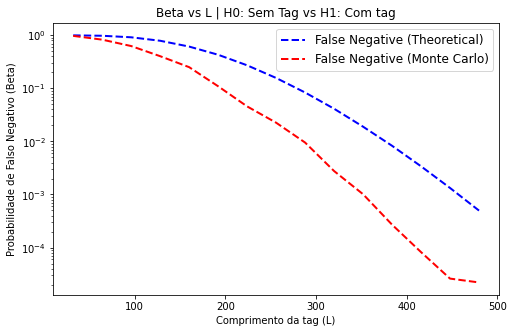

In [ ]:
#data = np.load("resultados_auth_fnr.npz")
L_values = range(32, 512, 32)
auth_prob = np.load("fnr_teorico.npz")["auth_prob"]
fnr_values = np.load("fnr_MonteCarlo_comruidodiferente.npz")["fnr_values"]
# Plot
plt.figure(figsize=(8, 5))
plt.semilogy(L_values, auth_prob,  '--b', linewidth=2, label='False Negative (Theoretical)')
plt.semilogy(L_values, fnr_values, '--r', linewidth=2, label='False Negative (Monte Carlo)')
plt.xlabel("Comprimento da tag (L)")
plt.ylabel("Probabilidade de Falso Negativo (Beta)")
plt.title("Beta vs L | H0: Sem Tag vs H1: Com tag")
plt.legend(loc='best', fontsize=12, frameon=True)
plt.show()

In [ ]:
from scipy.stats import norm

def plot_histogramas_teoricos(bpsk_msg, tag, rho_s, rho_t, sigma2v,L, tau=None, N_bins=40):
    """
    Plota histogramas teóricos das estatísticas tau|H0 e tau|H1 assumindo distribuição Gaussiana.

    Parâmetros:
        bpsk_msg : np.array
            Vetor da mensagem BPSK.
        tag : np.array
            Vetor da tag transmitida.
        rho_s : float
            Coeficiente da mensagem na combinação x = rho_s*msg + rho_t*tag
        rho_t : float
            Coeficiente da tag na combinação x = rho_s*msg + rho_t*tag
        sigma2v : float
            Variância da variável gaussiana da estatística
        tau : float, opcional
            Valor do limiar τ para plotar a linha vertical
        N_bins : int
            Número de bins no histograma (apenas referência para eixo x)
    """
    for i in range(1000):
        # Tamanho da estatística (supondo média sobre L amostras)
        chave= np.random.randint(0, 2, L+32) ###joao aqui calcula a energia de toda a seq de uma so vez
        bits_msg, bpsk_msg = modulator_bpsk(L)
        tag = generate_tag(L,L+32, bits_msg, chave)
        # Média teórica e variância de tau|H0
        mean_H0 = np.mean((((1 - rho_s) / rho_t) * bpsk_msg) * tag)
        var_H0 = sigma2v

        # Média teórica e variância de tau|H1
        mean_H1 = np.mean(tag**2)
        var_H1 = sigma2v

        # Definir intervalo para plot
        min_val = min(mean_H0 - 4*np.sqrt(var_H0), mean_H1 - 4*np.sqrt(var_H1))
        max_val = max(mean_H0 + 4*np.sqrt(var_H0), mean_H1 + 4*np.sqrt(var_H1))
        x = np.linspace(min_val, max_val, 1000)

        # Densidades teóricas
        pdf_H0 = norm.pdf(x, loc=mean_H0, scale=np.sqrt(var_H0))
        pdf_H1 = norm.pdf(x, loc=mean_H1, scale=np.sqrt(var_H1))

        # Plot
        plt.figure(figsize=(8,5))
        plt.plot(x, pdf_H0, label="H₀ (Sem Tag)", color="tab:blue", linewidth=2)
        plt.plot(x, pdf_H1, label="H₁ (Com TAG)", color="tab:orange", linewidth=2)

        # Linha do limiar
        if tau is not None:
            plt.axvline(tau, color="red", linestyle="--", linewidth=2, label=f"τ = {tau:.3f}")

        plt.title("Distribuições Teóricas de τ sob H₀ e H₁")
        plt.xlabel("Estatística do teste (τᵢ)")
        plt.ylabel("Densidade")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Exemplo de uso
plot_histogramas_teoricos(bpsk_msg, tag, rho_s, rho_t, sigma2v,L, tau=0.5)


In [ ]:
#histograma empirico:

# ====== Plot ======
"""
    plt.figure(figsize=(8, 5))
    plt.hist(stat_H0, bins=40, alpha=0.6, label="H₀ (Sem Tag)", color="tab:blue", density=True)
    plt.hist(stat_H1, bins=40, alpha=0.6, label="H₁ (Com TAG)", color="tab:orange", density=True)
    plt.axvline(tau, color="red", linestyle="--", linewidth=2, label=f"τ = {tau:.3f}")
    plt.title("Distribuições de Estatísticas sob H₀ e H₁")
    plt.xlabel("Estatística do teste (τᵢ)")
    plt.ylabel("Densidade")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

"""